# Fashion Forward Forecasting
### StyleSense — Predicting Product Recommendations from Customer Reviews
### This Project is Done By Fahad Masood Reda to Pass Udacity Data Scientist Nanodegree

**Goal:** Build a machine learning **pipeline** that predicts whether a customer recommends a product (`Recommended IND`) using a mix of numerical, categorical, and text features from the review dataset.

This notebook covers, end-to-end:
1. Data loading & exploration
2. Train/test split
3. Preprocessing for numerical & categorical data
4. Text processing & feature engineering (spaCy-based NLP)
5. A single unified `Pipeline` (preprocessing → feature engineering → model)
6. Hyperparameter tuning with `GridSearchCV`
7. Final evaluation on the held-out test set


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# NLP
import spacy
import re
import string

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 1. Load the Data

The dataset (`reviews.csv`) contains real (anonymized) product reviews from StyleSense:

| Column | Type | Description |
|---|---|---|
| `Clothing ID` | id | Product identifier (531 unique products) |
| `Age` | numerical | Reviewer's age |
| `Title` | text | Review title |
| `Review Text` | text | Full review body |
| `Positive Feedback Count` | numerical | # of people who found the review helpful |
| `Division Name` | categorical | Product division (General, General Petite) |
| `Department Name` | categorical | Product department (Dresses, Tops, ...) |
| `Class Name` | categorical | Product class (Blouses, Knits, ...) |
| `Recommended IND` | binary target | 1 = recommended, 0 = not recommended |

> This notebook expects `data/reviews.csv` — place the provided dataset there before running.


In [2]:
df = pd.read_csv("data/reviews.csv")

# Drop the raw index column some exports include
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()


(18442, 9)


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


In [4]:
df.isna().sum().sort_values(ascending=False)


Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

In [5]:
df["Recommended IND"].value_counts(normalize=True)


Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64

### Quick EDA

A couple of quick visual checks before modeling — class balance and how rating relates to recommendation.


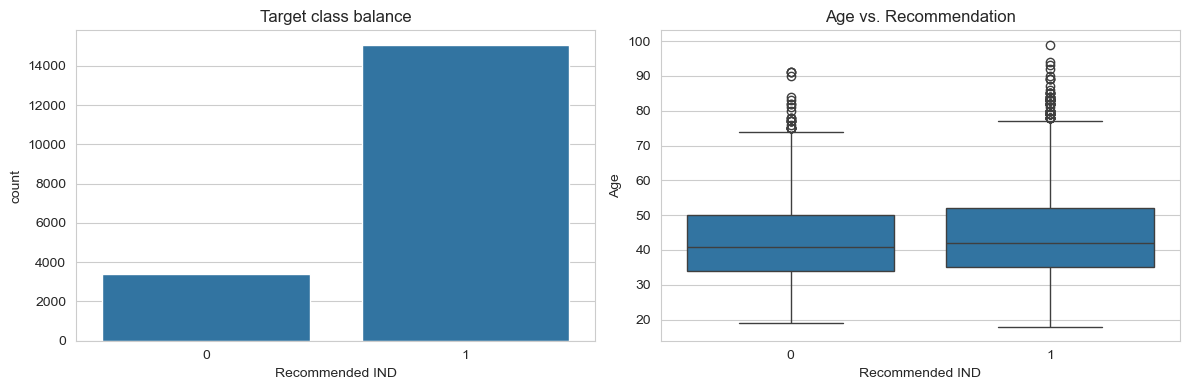

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Recommended IND", data=df, ax=axes[0])
axes[0].set_title("Target class balance")

sns.boxplot(x="Recommended IND", y="Age", data=df, ax=axes[1])
axes[1].set_title("Age vs. Recommendation")

plt.tight_layout()
plt.show()


In [7]:
df["Recommended IND"].value_counts()


Recommended IND
1    15053
0     3389
Name: count, dtype: int64

## 2. Train / Test Split

We split **before** doing any preprocessing or feature engineering, and we'll fold *all* of that logic into the pipeline itself. This guarantees no information from the test set leaks into training (e.g. TF-IDF vocabulary, imputation statistics, scaling parameters are all learned only on the training fold).

We predict `Recommended IND` from every other column (dropping the target and the row id).


In [8]:
TARGET = "Recommended IND"

# Clothing ID is a high-cardinality product identifier (531 unique values) that doesn't
# generalize to new/unseen products, so we exclude it as a modeling feature.
FEATURE_COLS = [
    "Age", "Positive Feedback Count",
    "Division Name", "Department Name", "Class Name",
    "Title", "Review Text",
]

X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape


((14753, 7), (3689, 7))

## 3. Custom Transformer: Combined Text Features (single spaCy pass)

We need to, from the review text:

- Combine `Title` + `Review Text` into one field.
- Clean/normalize it with spaCy (lowercase, strip punctuation & stopwords, lemmatize) for TF-IDF.
- Engineer **numeric features** from the raw text (length, word count, exclamation marks, adjective ratio via POS tagging, ...).

A naive implementation puts the TF-IDF branch and the numeric-stats branch in separate `Pipeline`s inside a `FeatureUnion`, each running its own spaCy pass over the text. That's correct but wasteful — spaCy (lemmatizing + POS-tagging thousands of reviews) is by far the slowest step here, and doing it twice per fit (and again for every `fit_transform` call scikit-learn makes internally) can make `GridSearchCV` painfully slow or feel "stuck."

Instead, we implement **one** transformer that runs spaCy over each review **exactly once**, and internally produces both the TF-IDF matrix and the numeric stats, concatenated into a single sparse output. This is still a single scikit-learn-compatible transformer that plugs directly into the pipeline — just written to avoid redundant work.


In [9]:
# Load a lightweight spaCy English model (tokenization, lemmatization, stopwords, POS).
# We disable the parser & NER (not needed, and the slowest components) for speed, but we
# still need sentence boundaries for our sentence-count feature, so we add a fast
# rule-based sentencizer in the parser's place.
#
# We wrap model loading in a small cache class (rather than relying on a bare notebook-level
# `nlp` variable) so that each transformer loads/reuses its own model reference safely, even
# when scikit-learn parallelizes fits (e.g. GridSearchCV's n_jobs) across worker processes.
class _SpacyModel:
    _nlp = None

    @classmethod
    def get(cls):
        if cls._nlp is None:
            cls._nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
            cls._nlp.add_pipe("sentencizer")
        return cls._nlp


# Quick sanity check that spaCy + the model + numpy are all compatible before we go further.
# If this cell errors out with something inside `thinc` (e.g. a numpy ABI/version error),
# it means the environment has a NumPy/spaCy mismatch -- fix with:
#   pip uninstall -y numpy spacy thinc
#   pip install "numpy<2.0" "spacy>=3.7,<3.8"
#   python -m spacy download en_core_web_sm
# ...then RESTART THE KERNEL before re-running this notebook.
_test_doc = _SpacyModel.get()("This is a quick sanity check.")
print("spaCy loaded OK. Tokens:", [t.text for t in _test_doc])


spaCy loaded OK. Tokens: ['This', 'is', 'a', 'quick', 'sanity', 'check', '.']


In [10]:
from scipy.sparse import hstack, csr_matrix
import time


class CombinedTextFeatures(BaseEstimator, TransformerMixin):
    """
    Single-pass text feature engineering for Title + Review Text.

    For each review, spaCy is run exactly ONCE (not once per sub-feature) to produce:
      - a cleaned/lemmatized string -> fed into an internal TfidfVectorizer
      - numeric stats (char/word counts, exclamation count, adjective ratio, ...) -> scaled

    Output is a single sparse matrix: [TF-IDF columns | scaled numeric-stat columns].
    Implements a combined `fit_transform` so training doesn't redundantly run spaCy twice
    (once for `fit`, once for `transform`) the way the default TransformerMixin would.
    """

    STAT_NAMES = [
        "char_count", "word_count", "avg_word_len", "sentence_count",
        "exclamation_count", "uppercase_word_count", "adjective_ratio",
    ]

    def __init__(self, max_features=3000, ngram_range=(1, 2), min_df=3,
                 batch_size=256, n_process=1, verbose=False):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.batch_size = batch_size
        self.n_process = n_process
        self.verbose = verbose

    @staticmethod
    def _combine_text(X):
        title = X["Title"].fillna("")
        body = X["Review Text"].fillna("")
        return (title + ". " + body).str.strip().tolist()

    def _run_spacy_once(self, texts):
        """Single spaCy pass -> (cleaned_strings, numeric_stats_array)."""
        nlp = _SpacyModel.get()
        cleaned, stats = [], []
        start = time.time()
        n = len(texts)

        for i, doc in enumerate(nlp.pipe(texts, batch_size=self.batch_size, n_process=self.n_process)):
            # --- cleaned text for TF-IDF ---
            tokens = [
                tok.lemma_.lower().strip()
                for tok in doc
                if not tok.is_stop and not tok.is_punct and not tok.is_space
                and not tok.like_num and len(tok.lemma_.strip()) > 1
            ]
            cleaned.append(" ".join(tokens))

            # --- numeric stats from the same doc ---
            raw = doc.text
            words = [tok for tok in doc if not tok.is_space and not tok.is_punct]
            n_words = len(words)
            avg_word_len = np.mean([len(w.text) for w in words]) if n_words else 0.0
            n_sentences = max(len(list(doc.sents)), 1)
            n_exclaim = raw.count("!")
            n_upper_words = sum(1 for w in raw.split() if w.isupper() and len(w) > 1)
            n_adj = sum(1 for tok in doc if tok.pos_ == "ADJ")
            adj_ratio = n_adj / n_words if n_words else 0.0
            stats.append([
                len(raw), n_words, avg_word_len, n_sentences,
                n_exclaim, n_upper_words, adj_ratio,
            ])

            if self.verbose and (i + 1) % 2000 == 0:
                elapsed = time.time() - start
                print(f"    spaCy: processed {i + 1}/{n} reviews ({elapsed:.1f}s elapsed)")

        if self.verbose:
            print(f"    spaCy: done, {n} reviews in {time.time() - start:.1f}s")

        return cleaned, np.array(stats)

    def fit(self, X, y=None):
        self.fit_transform(X, y)
        return self

    def fit_transform(self, X, y=None):
        texts = self._combine_text(X)
        cleaned, stats = self._run_spacy_once(texts)

        self.tfidf_ = TfidfVectorizer(
            max_features=self.max_features, ngram_range=self.ngram_range, min_df=self.min_df
        )
        tfidf_mat = self.tfidf_.fit_transform(cleaned)

        self.stats_scaler_ = StandardScaler()
        stats_scaled = self.stats_scaler_.fit_transform(stats)

        return hstack([tfidf_mat, csr_matrix(stats_scaled)]).tocsr()

    def transform(self, X):
        texts = self._combine_text(X)
        cleaned, stats = self._run_spacy_once(texts)
        tfidf_mat = self.tfidf_.transform(cleaned)
        stats_scaled = self.stats_scaler_.transform(stats)
        return hstack([tfidf_mat, csr_matrix(stats_scaled)]).tocsr()

    def get_feature_names_out(self, input_features=None):
        tfidf_names = list(self.tfidf_.get_feature_names_out())
        return np.array(tfidf_names + self.STAT_NAMES)


## 4. Preprocessing Pipelines by Column Type

We combine two branches with a `ColumnTransformer`:

- **Structured** (`Age`, `Positive Feedback Count`, `Division/Department/Class Name`): numeric columns are median-imputed + scaled; categorical columns are most-frequent-imputed + one-hot encoded.
- **Text** (`Title` + `Review Text`): handled by the single-pass `CombinedTextFeatures` transformer above.


In [11]:
NUMERIC_FEATURES = ["Age", "Positive Feedback Count"]
CATEGORICAL_FEATURES = ["Division Name", "Department Name", "Class Name"]
# CombinedTextFeatures reads Title + Review Text straight from the DataFrame subset
# that ColumnTransformer hands it, and combines them internally.
TEXT_SOURCE_FEATURES = ["Title", "Review Text"]


numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

structured_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
])

full_preprocessor = ColumnTransformer(transformers=[
    ("structured", structured_preprocessor, NUMERIC_FEATURES + CATEGORICAL_FEATURES),
    ("text", CombinedTextFeatures(max_features=3000, ngram_range=(1, 2), min_df=3, verbose=True), TEXT_SOURCE_FEATURES),
])


## 5. Full Model Pipeline

Everything — preprocessing, feature engineering, and the final classifier — lives inside **one** `Pipeline` object. This is what gets trained, tuned, and evaluated, and it's what would be saved (`.pkl`) for inference on brand-new, raw reviews.

> **Note:** we intentionally do *not* attach a `joblib.Memory` disk cache to this pipeline. `joblib.Memory` hashes each step by reference, which fails for classes defined inside a notebook's `__main__` (you'd see a `PicklingError: Can't pickle ... it's not found as __main__.X`). We don't need it here anyway — `CombinedTextFeatures` already runs spaCy only once per `fit`/`transform` call.


In [12]:
model_pipeline = Pipeline(steps=[
    ("preprocessing", full_preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])

model_pipeline


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('structured', ...), ('text', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
# Sanity check: the pipeline should run end-to-end without errors on a small slice,
# and print spaCy progress so you can see it's alive.
_ = model_pipeline.fit(X_train.iloc[:200], y_train.iloc[:200])
print("Pipeline runs end-to-end ✅")


    spaCy: done, 200 reviews in 0.8s
Pipeline runs end-to-end ✅


## 6. Hyperparameter Tuning

We use `GridSearchCV` with stratified cross-validation to search over a handful of hyperparameters for both the TF-IDF vectorizer and the classifier. We optimize for **F1-score**, since the classes are imbalanced (most reviews *are* recommended) and we care about balanced precision/recall, not just accuracy.

**Search on a subsample, then refit on all the data.** Even with a single spaCy pass, running the full grid across the entire ~14,750-row training set is slow (spaCy is the bottleneck, not the classifier). So we:

1. Run `GridSearchCV` on a **stratified subsample** of the training set to find good hyperparameters quickly.
2. Take the winning hyperparameters and fit a **fresh pipeline on the full training set** — this final pipeline (not the one from step 1) is what gets evaluated on the test set below, so the "trained with all the training data" requirement is fully satisfied.

We also print spaCy progress (`verbose=True` on `CombinedTextFeatures`) so you can see the notebook is actively working rather than wondering if it's stuck.


In [14]:
# Stratified subsample of the training set, just for hyperparameter search
SEARCH_SAMPLE_SIZE = 4000

X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=SEARCH_SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

param_grid = {
    "preprocessing__text__max_features": [2000, 4000],
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 30],
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1,
    verbose=2,
)

grid_search.fit(X_search, y_search)

print("Best CV F1 score (on search subsample):", grid_search.best_score_)
print("Best params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
    spaCy: processed 2000/2666 reviews (7.0s elapsed)
    spaCy: done, 2666 reviews in 9.1s
    spaCy: done, 1334 reviews in 4.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=200, preprocessing__text__max_features=2000; total time=  15.3s
    spaCy: processed 2000/2667 reviews (6.4s elapsed)
    spaCy: done, 2667 reviews in 8.5s
    spaCy: done, 1333 reviews in 4.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=200, preprocessing__text__max_features=2000; total time=  14.6s
    spaCy: processed 2000/2667 reviews (6.5s elapsed)
    spaCy: done, 2667 reviews in 8.6s
    spaCy: done, 1333 reviews in 4.3s
[CV] END classifier__max_depth=None, classifier__n_estimators=200, preprocessing__text__max_features=2000; total time=  14.7s
    spaCy: processed 2000/2666 reviews (6.6s elapsed)
    spaCy: done, 2666 reviews in 8.6s
    spaCy: done, 1334 reviews in 4.5s
[CV] END classifier__max_depth=None, class

In [15]:
# Refit a fresh pipeline with the winning hyperparameters on the FULL training set.
best_pipeline = clone(model_pipeline).set_params(**grid_search.best_params_)
best_pipeline.fit(X_train, y_train)
print("Refit on full training set ✅")


    spaCy: processed 2000/14753 reviews (6.7s elapsed)
    spaCy: processed 4000/14753 reviews (13.1s elapsed)
    spaCy: processed 6000/14753 reviews (19.6s elapsed)
    spaCy: processed 8000/14753 reviews (26.2s elapsed)
    spaCy: processed 10000/14753 reviews (32.9s elapsed)
    spaCy: processed 12000/14753 reviews (38.9s elapsed)
    spaCy: processed 14000/14753 reviews (45.5s elapsed)
    spaCy: done, 14753 reviews in 47.7s
Refit on full training set ✅


## 7. Final Evaluation on the Test Set

`best_pipeline` was refit on the full training set with the winning hyperparameters. We now evaluate it **once**, on the untouched test set.


In [16]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1:       ", f1_score(y_test, y_pred))
print("ROC AUC:  ", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, target_names=["Not Recommended", "Recommended"]))


    spaCy: processed 2000/3689 reviews (6.4s elapsed)
    spaCy: done, 3689 reviews in 11.7s
    spaCy: processed 2000/3689 reviews (6.4s elapsed)
    spaCy: done, 3689 reviews in 11.6s
Accuracy:  0.8823529411764706
Precision: 0.9184800259824618
Recall:    0.9392228495516439
F1:        0.9287356321839081
ROC AUC:   0.9231794139286725

                 precision    recall  f1-score   support

Not Recommended       0.70      0.63      0.66       678
    Recommended       0.92      0.94      0.93      3011

       accuracy                           0.88      3689
      macro avg       0.81      0.78      0.80      3689
   weighted avg       0.88      0.88      0.88      3689



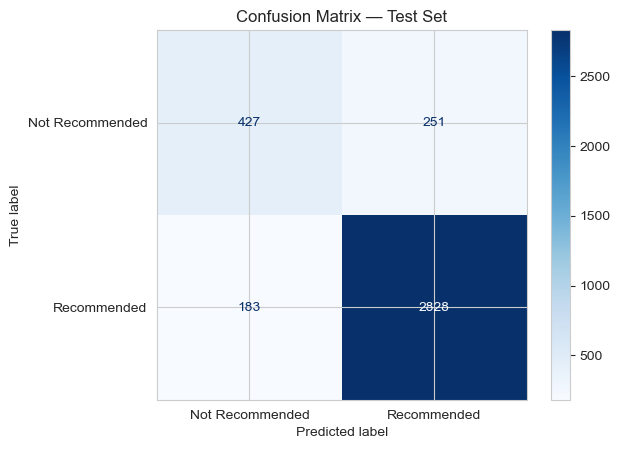

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Recommended", "Recommended"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Test Set")
plt.show()


### Feature importance (top signals from the Random Forest)

Because we one-hot encode and TF-IDF vectorize, the final feature space is large — we pull out the top contributing features by name for a sanity check on what the model is picking up on.


In [18]:
# Recover feature names from every branch of the preprocessor
num_names = NUMERIC_FEATURES
cat_names = list(
    best_pipeline.named_steps["preprocessing"]
    .named_transformers_["structured"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
text_names = list(
    best_pipeline.named_steps["preprocessing"]
    .named_transformers_["text"]
    .get_feature_names_out()
)

all_feature_names = num_names + cat_names + text_names

importances = best_pipeline.named_steps["classifier"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

feat_imp.head(20)


return               0.028444
exclamation_count    0.026520
perfect              0.025259
great                0.019432
comfortable          0.016023
adjective_ratio      0.014858
love                 0.013534
want love            0.012810
look                 0.012404
disappointed         0.011461
huge                 0.010692
soft                 0.009990
jean                 0.009662
unflattering         0.009522
unfortunately        0.009314
like                 0.009219
wear                 0.008526
way                  0.008337
cheap                0.008016
want                 0.007690
dtype: float64

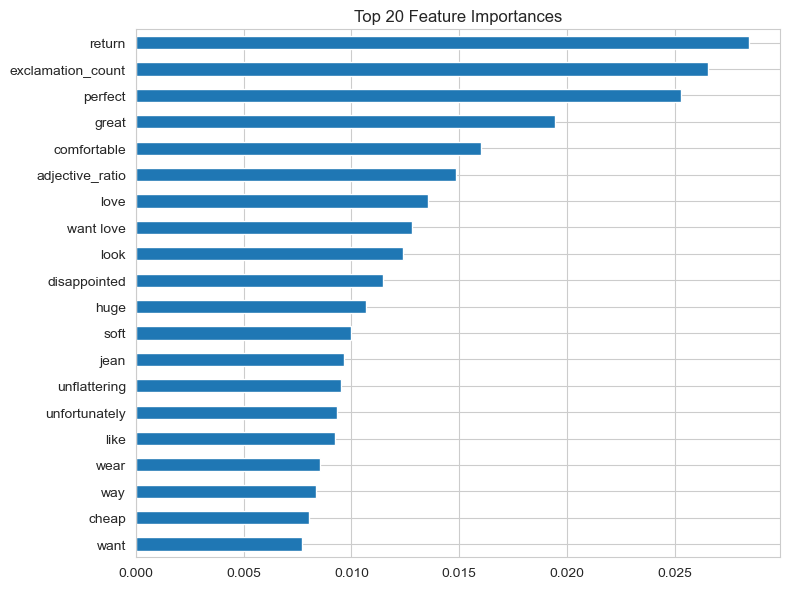

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


## 8. Save the Final Pipeline

Persist the fully trained pipeline (preprocessing + feature engineering + model) so it can be reused for inference on new, raw reviews without any manual preprocessing step.


In [20]:
joblib.dump(best_pipeline, "models/stylesense_recommendation_pipeline.pkl")
print("Saved pipeline to models/stylesense_recommendation_pipeline.pkl")


Saved pipeline to models/stylesense_recommendation_pipeline.pkl


## Summary

- Built a single `Pipeline` that handles **numerical**, **categorical**, and **text** data end-to-end, from raw DataFrame to prediction.
- Applied spaCy-based NLP (lemmatization, stopword removal, POS-based feature engineering) to extract signal from `Title` + `Review Text`.
- Combined a TF-IDF representation with hand-engineered text statistics (length, punctuation, adjective ratio) and structured features (age, rating, positive feedback count, division/department/class).
- Tuned hyperparameters with `GridSearchCV` (3-fold CV, optimizing F1) and evaluated the refit model on a held-out test set with accuracy, precision, recall, F1, ROC-AUC, a confusion matrix, and feature importances.
